In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/isingdata-h5py-jb/G1_J1_data.h5py
/kaggle/input/isingdata-h5py-jb/Gp5_data.h5py
/kaggle/input/isingdata-h5py-jb/Gp1_data.h5py
/kaggle/input/isingdata-h5py-jb/G1_Jp01_data.h5py
/kaggle/input/isingdata-h5py-jb/G0_data.h5py


In [2]:
from __future__ import print_function, division
import os,sys
import numpy as np
import torch # pytorch package, allows using GPUs
# fix seed
seed=17
np.random.seed(seed)
torch.manual_seed(seed)

import pandas as pd
from tqdm.notebook import tqdm
from tqdm.notebook import trange
import pickle
import matplotlib.pyplot as plt

import time
start = time.time()

In [3]:
# Folder names
images_folder_name = "images_for_Models_trained_on_non_cirtical_data"

if not os.path.isdir(images_folder_name):
    os.mkdir(images_folder_name)
    
if not os.path.isdir("Generated_plots"):
    os.mkdir("Generated_plots")

if not os.path.isdir(os.path.join("Generated_plots","accuracies_and_losses")):
    os.mkdir(os.path.join("Generated_plots","accuracies_and_losses"))

## Required Functions,Methods Transforms etc

In [4]:
import numpy as np


def Magnetization(configeration):
    """Given the configeration this functions outputs the total magnetization
    of that configeration"""
    return np.average(np.average(configeration))


def energy(configeration, J):
    """Give a configeration and value of J this functions caluculates the
    energy of the configeration considering the nearest neighbout interactions
    without external magnetic field """
    # E=-J*($\sum_{<i,j>}\sigma_i * \sigma_j $ )
    L = configeration.shape[0]
    Energy = 0

    for i in range(L):
        for j in range(L):
            S = configeration[i, j]
            nb_spins = neighbouring_spins(configeration, (i, j))
            Energy += np.sum(S * nb_spins)

    Energy = -0.5 * J * Energy
    return Energy


def energy2(configeration, J):
    """Same as energy(configeration, J) just faster"""
    L = configeration.shape[0]
    Energy = 0

    Energy += np.sum(np.sum(configeration[:, :-1] * configeration[:, 1:]))
    Energy += np.sum(np.sum(configeration[:, 0] * configeration[:, -1]))
    Energy += np.sum(np.sum(configeration[:-1, :] * configeration[1:, :]))
    Energy += np.sum(np.sum(configeration[0, :] * configeration[-1, :]))
    Energy = -J * Energy
    return Energy


def magnetic_susceptibility(Magnetization_list, T):
    k_b = 1
    beta = 1/(k_b*T)
    # N = L * L
    chi = (beta) * (np.average(Magnetization_list * Magnetization_list) -
                    np.average(np.abs(Magnetization_list))**2)
    return chi


# Transform
class Random_shuffle_Transform:
    """Given a configeration this transform randomly shuffles
    the configeration and retuns a new configeration without
    effecting the old one

    In this Class Labels will be uneffected.
    """

    def __call__(self, sample):
        inputs, targets = sample
        L1, L2 = inputs.shape
        inputs_transformed = np.copy(inputs)
        inputs_transformed = inputs_transformed.reshape(L1 * L2)
        rng = np.random.default_rng()
        inputs_transformed = rng.permutation(inputs_transformed)
        inputs_transformed = inputs_transformed.reshape(L1, L2)

        return inputs_transformed, targets


def Random_shuffle_configerations(input_configeration_array):
    """Give a an input array of shape (N, L1, L2) keeping the 
    N index fixed the functions Randomly shuffles the data in
    L1 and L2 indices i.e Given an array with N configeration
    this function shuffles the spins inside each configeration """
    N, L1, L2 = input_configeration_array.shape
    output_configeration_array = np.copy(input_configeration_array)
    output_configeration_array = output_configeration_array.reshape(
        -1, L1 * L2)
    for i in range(N):
        rng = np.random.default_rng()
        output_configeration_array[i] = rng.permutation(
            output_configeration_array[i])
    output_configeration_array = output_configeration_array.reshape(N, L1, L2)

    return output_configeration_array

In [5]:
%%time

import h5py
f5_G0 = h5py.File("../input/isingdata-h5py-jb/G0_data.h5py")
f5_G1_J0 = h5py.File("../input/isingdata-h5py-jb/G1_Jp01_data.h5py")
f5_G1_J1 = h5py.File("../input/isingdata-h5py-jb/G1_J1_data.h5py")
f5_Gp1 = h5py.File("../input/isingdata-h5py-jb/Gp1_data.h5py")
f5_Gp5 = h5py.File("../input/isingdata-h5py-jb/Gp5_data.h5py")

CPU times: user 43.1 ms, sys: 23.8 ms, total: 66.9 ms
Wall time: 253 ms


# Creating a data frame to store the critical temperatute for differnt data types

In [6]:
crit_region_dict = {"J":[], "G":[], "T_low_for_critical":[], "T_up_for_critical":[], "T_critical":[],"Temperature Range":[],"T_c Range":[]}
df_crit_region_temps = pd.DataFrame(crit_region_dict)

## Loading G=0.0 Data and converting them to .pkl files

In [7]:
%%time

#------------------------------------------
import pickle
#------------------------------------------

# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
Targs=np.arange(61)
L = 40
T_array = f5_G0['Ts'][:]
G = 0.0
J = 1.0

# folder name for saving the G=0.0 data in .pkl format
G_0_pkl_folder_path = f"G_0_data_in_pkl_format"
if not os.path.isdir(G_0_pkl_folder_path):
    os.mkdir(G_0_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_G0['arrs'][i,:,:].reshape(-1, L, L).astype("int8")
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
# print(data_output_file_name)
    path = os.path.join(G_0_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 9.77 s, sys: 4.29 s, total: 14.1 s
Wall time: 18 s


,J,G,T_low_for_critical,T_up_for_critical,T_critical,Temperature Range,T_c Range
0,1.0,0.0,2.2,2.625,2.3375,"[1.000,4.000]","[2.325,2.350]"


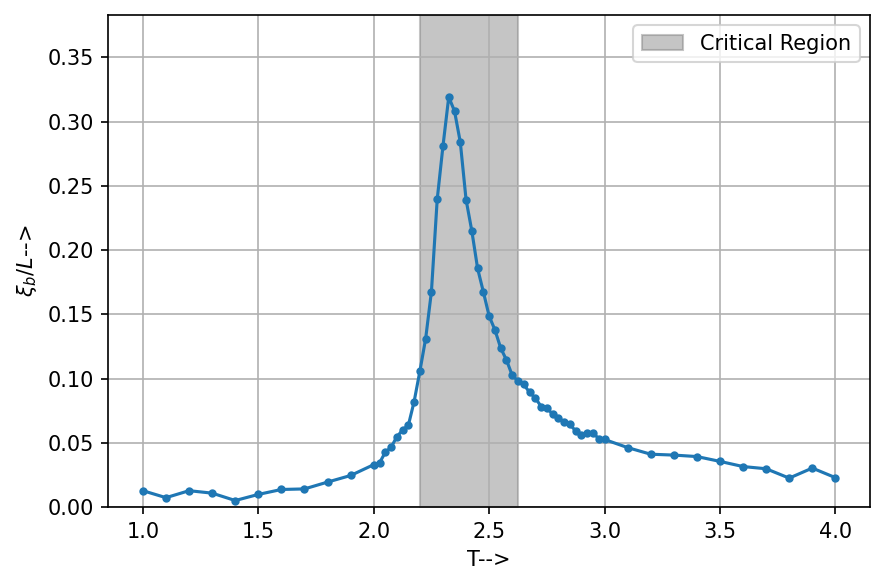

In [8]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(61)
xiBs=f5_G0['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]
crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2

T_low_for_critical = T_array[crit_start]
T_up_for_critical = T_array[crit_end]
T_critical = crit_Temp
#---------------------------------------

plt.figure(dpi=150)
plt.plot(T_array, xiBs,".-")
plt.fill_betweenx([0, np.amax(xiBs)*1.2], T_low_for_critical, T_up_for_critical, color='gray', alpha=0.45,label="Critical Region")
# plt.title(f"xiBs for G={G}, J={J} ")
plt.ylim([0, np.amax(xiBs)*1.2])
plt.xlabel("T-->")
plt.ylabel(rf"$\xi_b/L$-->")
plt.legend()
plt.grid()
figure_name = f"xi_b_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0":list(T_array), "xi_b_list_G_0":list(xiBs)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# Storing the data for future use
temp_dict = {"J":J, "G":G, "T_low_for_critical":T_low_for_critical, "T_up_for_critical":T_up_for_critical, "T_critical":T_critical}
temp_dict["Temperature Range"] = f"[{T_array[0]:.3f},{T_array[-1]:.3f}]"
temp_dict["T_c Range"] = f"[{T_array[xiBs.argsort()[-1]]:.3f},{T_array[xiBs.argsort()[-2]]:.3f}]"
df_crit_region_temps = df_crit_region_temps.append(temp_dict, ignore_index = True)
df_crit_region_temps

## G=0.1

In [9]:
%%time
# G = 0.1 data
# Converting the Raw data with G=0.1 into the data type I need (.pkl files)
 
# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
L = 40
T_array = f5_Gp1['Ts'][:]
G = 0.1
J = 1.0

# folder name for saving the G=0.1 data in .pkl format
G_0_1_pkl_folder_path = f"G_0.1_data_in_pkl_format"
if not os.path.isdir(G_0_1_pkl_folder_path):
    os.mkdir(G_0_1_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_Gp1['arrs'][i,:,:].reshape(-1, L, L).astype("int8") 
    
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
    # print(data_output_file_name)
    path = os.path.join(G_0_1_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 8.96 s, sys: 4.75 s, total: 13.7 s
Wall time: 16.9 s


,J,G,T_low_for_critical,T_up_for_critical,T_critical,Temperature Range,T_c Range
0,1.0,0.0,2.200,2.625,2.3375,"[1.000,4.000]","[2.325,2.350]"
1,1.0,0.1,2.525,2.975,2.6625,"[1.000,4.000]","[2.675,2.650]"


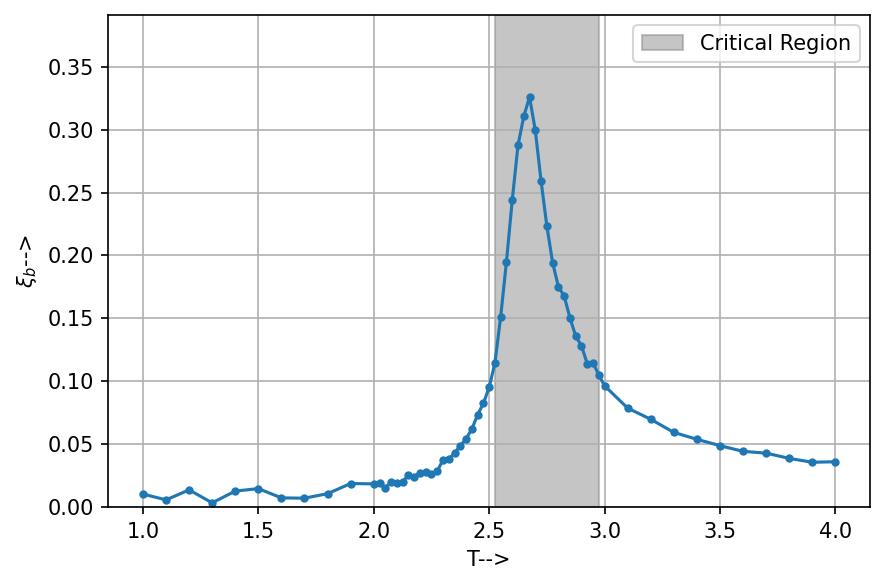

In [10]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(61)
xiBs=f5_Gp1['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]
crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2

T_low_for_critical = T_array[crit_start]
T_up_for_critical = T_array[crit_end]
T_critical = crit_Temp
#---------------------------------------

plt.figure(dpi=150)
plt.plot(T_array, xiBs,".-")
plt.fill_betweenx([0, np.amax(xiBs)*1.2], T_low_for_critical, T_up_for_critical, color='gray', alpha=0.45,label="Critical Region")
# plt.title(f"xiBs for G={G}, J={J} ")
plt.ylim([0, np.amax(xiBs)*1.2])
plt.xlabel("T-->")
plt.ylabel(rf"$\xi_b$-->")
plt.legend()
plt.grid()
figure_name = f"xi_b_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0_1":list(T_array), "xi_b_list_G_0_1":list(xiBs)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# Storing the data for future use
temp_dict = {"J":J, "G":G, "T_low_for_critical":T_low_for_critical, "T_up_for_critical":T_up_for_critical, "T_critical":T_critical}
temp_dict["Temperature Range"] = f"[{T_array[0]:.3f},{T_array[-1]:.3f}]"
temp_dict["T_c Range"] = f"[{T_array[xiBs.argsort()[-1]]:.3f},{T_array[xiBs.argsort()[-2]]:.3f}]"
df_crit_region_temps = df_crit_region_temps.append(temp_dict, ignore_index = True)
df_crit_region_temps

# G=0.5

In [11]:
%%time
# G = 0.5 data
# Converting the Raw data with G=0.5 into the data type I need (.pkl files)


# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
L = 40
T_array = f5_Gp5['Ts'][:]
G = 0.5
J = 1.0

# folder name for saving the G=0.5 data in .pkl format
G_0_5_pkl_folder_path = f"G_0.5_data_in_pkl_format"
if not os.path.isdir(G_0_5_pkl_folder_path):
    os.mkdir(G_0_5_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_Gp5['arrs'][i,:,:].reshape(-1, L, L).astype("int8")
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
    # print(data_output_file_name)
    path = os.path.join(G_0_5_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 9.76 s, sys: 4.58 s, total: 14.3 s
Wall time: 18.3 s


,J,G,T_low_for_critical,T_up_for_critical,T_critical,Temperature Range,T_c Range
0,1.0,0.0,2.200,2.625,2.3375,"[1.000,4.000]","[2.325,2.350]"
1,1.0,0.1,2.525,2.975,2.6625,"[1.000,4.000]","[2.675,2.650]"
2,1.0,0.5,3.725,4.350,3.9125,"[2.500,5.500]","[3.900,3.925]"


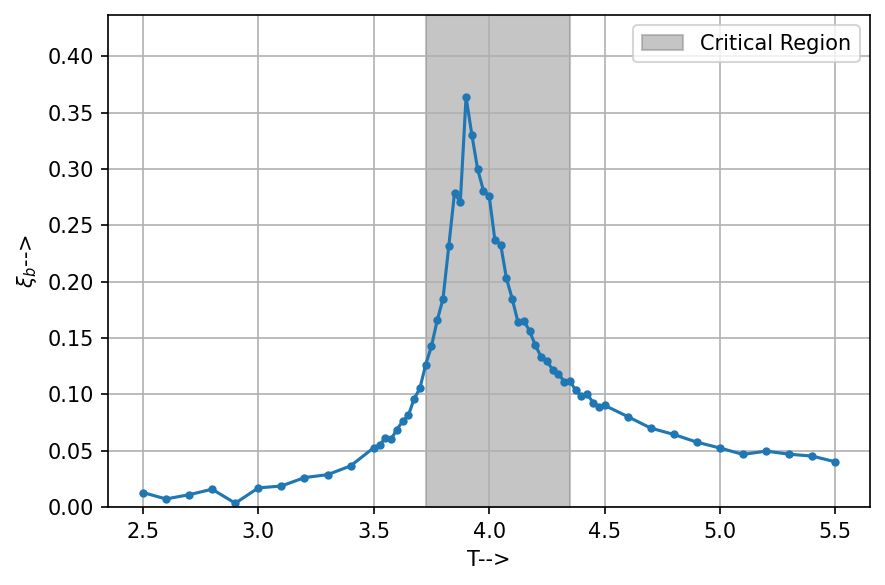

In [12]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(61)
xiBs=f5_Gp5['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]
crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2

T_low_for_critical = T_array[crit_start]
T_up_for_critical = T_array[crit_end]
T_critical = crit_Temp
#---------------------------------------

plt.figure(dpi=150)
plt.plot(T_array, xiBs,".-")
plt.fill_betweenx([0, np.amax(xiBs)*1.2], T_low_for_critical, T_up_for_critical, color='gray', alpha=0.45,label="Critical Region")
# plt.title(f"xiBs for G={G}, J={J} ")
plt.ylim([0, np.amax(xiBs)*1.2])
plt.xlabel("T-->")
plt.ylabel(rf"$\xi_b$-->")
plt.legend()
plt.grid()
figure_name = f"xi_b_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0_5":list(T_array), "xi_b_list_G_0_5":list(xiBs)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# Storing the data for future use
temp_dict = {"J":J, "G":G, "T_low_for_critical":T_low_for_critical, "T_up_for_critical":T_up_for_critical, "T_critical":T_critical}
temp_dict["Temperature Range"] = f"[{T_array[0]:.3f},{T_array[-1]:.3f}]"
temp_dict["T_c Range"] = f"[{T_array[xiBs.argsort()[-1]]:.3f},{T_array[xiBs.argsort()[-2]]:.3f}]"
df_crit_region_temps = df_crit_region_temps.append(temp_dict, ignore_index = True)
df_crit_region_temps

## G = 1.0 , J=0.0

In [13]:
%%time
# G = 1.0 , J=0.0 data
# Converting the Raw data with G = 1.0 , J=0.0 into the data type I need (.pkl files)


# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
L = 40
T_array = f5_G1_J0['Ts'][:]
G = 1.0
J = 0.0

# folder name for saving the G=0.5 data in .pkl format
G_1_J_0_pkl_folder_path = f"G_1_J_0_data_in_pkl_format"
if not os.path.isdir(G_1_J_0_pkl_folder_path):
    os.mkdir(G_1_J_0_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_G1_J0['arrs'][i,:,:].reshape(-1, L, L).astype("int8")
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
    # print(data_output_file_name)
    path = os.path.join(G_1_J_0_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/61 [00:00<?, ?it/s]

CPU times: user 9.54 s, sys: 4.83 s, total: 14.4 s
Wall time: 18.2 s


,J,G,T_low_for_critical,T_up_for_critical,T_critical,Temperature Range,T_c Range
0,1.0,0.0,2.200,2.625,2.3375,"[1.000,4.000]","[2.325,2.350]"
1,1.0,0.1,2.525,2.975,2.6625,"[1.000,4.000]","[2.675,2.650]"
2,1.0,0.5,3.725,4.350,3.9125,"[2.500,5.500]","[3.900,3.925]"
3,0.0,1.0,2.350,2.825,2.4875,"[1.000,4.000]","[2.475,2.500]"


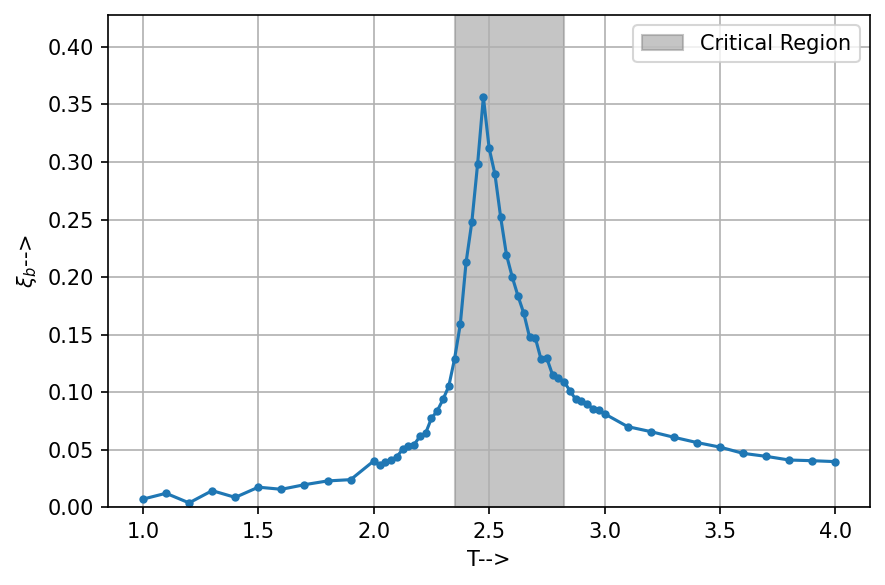

In [14]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(61)
xiBs=f5_G1_J0['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]
crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2
T_low_for_critical = T_array[crit_start]
T_up_for_critical = T_array[crit_end]
T_critical = crit_Temp
#---------------------------------------

plt.figure(dpi=150)
plt.plot(T_array, xiBs,".-")
plt.fill_betweenx([0, np.amax(xiBs)*1.2], T_low_for_critical, T_up_for_critical, color='gray', alpha=0.45,label="Critical Region")
# plt.title(f"xiBs for G={G}, J={J} ")
plt.ylim([0, np.amax(xiBs)*1.2])
plt.xlabel("T-->")
plt.ylabel(rf"$\xi_b$-->")
plt.legend()
plt.grid()
figure_name = f"xi_b_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_1_J_0":list(T_array), "xi_b_list_G_1_J_0":list(xiBs)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# Storing the data for future use
temp_dict = {"J":J, "G":G, "T_low_for_critical":T_low_for_critical, "T_up_for_critical":T_up_for_critical, "T_critical":T_critical}
temp_dict["Temperature Range"] = f"[{T_array[0]:.3f},{T_array[-1]:.3f}]"
temp_dict["T_c Range"] = f"[{T_array[xiBs.argsort()[-1]]:.3f},{T_array[xiBs.argsort()[-2]]:.3f}]"
df_crit_region_temps = df_crit_region_temps.append(temp_dict, ignore_index = True)
df_crit_region_temps

## G = 1.0 , J=1.0

In [15]:
%%time
# G = 1.0 , J=1.0 data
# Converting the Raw data with G = 1.0 , J=1.0 into the data type I need (.pkl files)


# Copied mostly from my Data_read_folder_specific.py file with necessory changes  
# -----------------------------------------------------------------------------------
# Parameters
L = 40
T_array = f5_G1_J1['Ts'][:]
G = 1.0
J = 1.0

# folder name for saving the G=0.5 data in .pkl format
G_1_J_1_pkl_folder_path = f"G_1_J_1_data_in_pkl_format"
if not os.path.isdir(G_1_J_1_pkl_folder_path):
    os.mkdir(G_1_J_1_pkl_folder_path)

No_configerations_for_each_T = 10000 
for i in trange(T_array.shape[0]):
    T = T_array[i]
    data = f5_G1_J1['arrs'][i,:,:].reshape(-1, L, L).astype("int8")
    
    data_output_file_name = f"configerations_L_{L}_G_{G:.2f}_J_{J:.2f}_T_{T:.6f}_.pkl"
    # print(data_output_file_name)
    path = os.path.join(G_1_J_1_pkl_folder_path, data_output_file_name)
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    
# -----------------------------------------------------------------------------------
# To save space
del data

  0%|          | 0/80 [00:00<?, ?it/s]

CPU times: user 12 s, sys: 6.28 s, total: 18.3 s
Wall time: 22.7 s


,J,G,T_low_for_critical,T_up_for_critical,T_critical,Temperature Range,T_c Range
0,1.0,0.0,2.200,2.625,2.3375,"[1.000,4.000]","[2.325,2.350]"
1,1.0,0.1,2.525,2.975,2.6625,"[1.000,4.000]","[2.675,2.650]"
2,1.0,0.5,3.725,4.350,3.9125,"[2.500,5.500]","[3.900,3.925]"
3,0.0,1.0,2.350,2.825,2.4875,"[1.000,4.000]","[2.475,2.500]"
4,1.0,1.0,5.100,6.100,5.3625,"[2.000,7.000]","[5.375,5.350]"


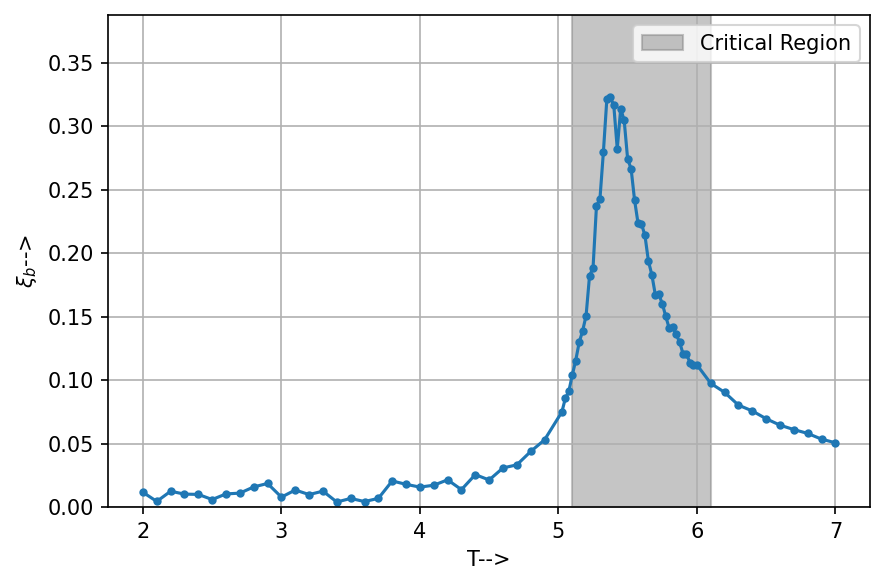

In [16]:
#---------------------------------------
#Critical Region: 
#---------------------------------------
Targs=np.arange(80)
xiBs=f5_G1_J1['xiBs'][:]
factor=0.30 # Parameter which determines critical region
cut=np.amax(xiBs)*factor
labels_tmp=np.heaviside(xiBs[Targs]-cut,1.0)
crit_start=np.where(labels_tmp==1.0)[0][0]
crit_end=np.where(labels_tmp==1.0)[0][-1]
crit_Temp=(T_array[xiBs.argsort()[-1]]+T_array[xiBs.argsort()[-2]])/2
T_low_for_critical = T_array[crit_start]
T_up_for_critical = T_array[crit_end]
T_critical = crit_Temp
#---------------------------------------

plt.figure(dpi=150)
plt.plot(T_array, xiBs,".-")
plt.fill_betweenx([0, np.amax(xiBs)*1.2], T_low_for_critical, T_up_for_critical, color='gray', alpha=0.45,label="Critical Region")
# plt.title(f"xiBs for G={G}, J={J} ")
plt.ylim([0, np.amax(xiBs)*1.2])
plt.xlabel("T-->")
plt.ylabel(rf"$\xi_b$-->")
plt.legend()
plt.grid()
figure_name = f"xi_b_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_1_J_1":list(T_array), "xi_b_list_G_1_J_1":list(xiBs)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# Storing the data for future use
temp_dict = {"J":J, "G":G, "T_low_for_critical":T_low_for_critical, "T_up_for_critical":T_up_for_critical, "T_critical":T_critical}
temp_dict["Temperature Range"] = f"[{T_array[0]:.3f},{T_array[-1]:.3f}]"
temp_dict["T_c Range"] = f"[{T_array[xiBs.argsort()[-1]]:.3f},{T_array[xiBs.argsort()[-2]]:.3f}]"
df_crit_region_temps = df_crit_region_temps.append(temp_dict, ignore_index = True)
df_crit_region_temps

## Magnetization Plot

CPU times: user 1min 37s, sys: 2.96 s, total: 1min 40s
Wall time: 1min 39s


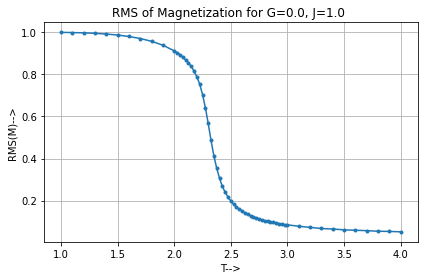

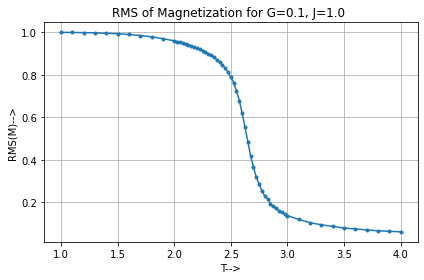

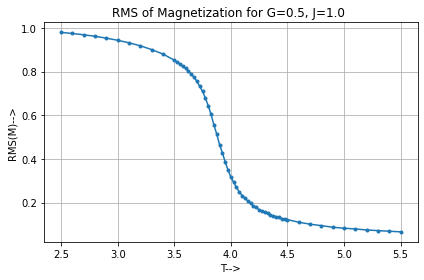

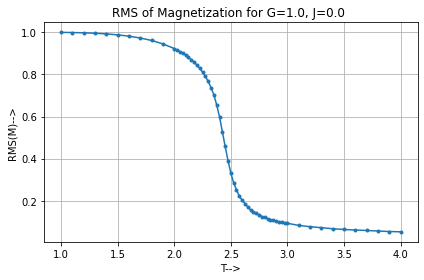

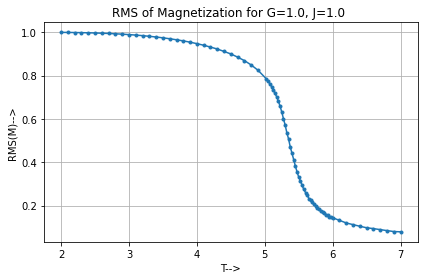

In [17]:
%%time
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt



# Saving all the file names into a dictionary called data file name
data_file_names_list_G_0 = []
for file_name in os.listdir("./G_0_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_0.append(file_name)
data_file_names_list_G_0.sort()

data_file_names_list_G_0_1 = []
for file_name in os.listdir("./G_0.1_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_0_1.append(file_name)
data_file_names_list_G_0_1.sort()

data_file_names_list_G_0_5 = []
for file_name in os.listdir("./G_0.5_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_0_5.append(file_name)
data_file_names_list_G_0_5.sort()

data_file_names_list_G_1_J_0 = []
for file_name in os.listdir("./G_1_J_0_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_1_J_0.append(file_name)
data_file_names_list_G_1_J_0.sort()


data_file_names_list_G_1_J_1 = []
for file_name in os.listdir("./G_1_J_1_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_1_J_1.append(file_name)
data_file_names_list_G_1_J_1.sort()

if not os.path.isdir("Generated_plots"):
    os.mkdir("Generated_plots")

# ------------------------------------------------------------------------------------------------------------------------<

# Plotting The RMS_Magnetization as function of Temperatute at G=0.0-----------------<
T_list_G_0 = [] 
RMS_Magnetization_list_G_0 = [] 
for configerations_file_name in data_file_names_list_G_0:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_0_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            RMS_Magnetization = np.sqrt(np.average(np.square(Magnetization_list)))
            # Average_absolute_Magnetization = np.average(np.abs(Magnetization_list))
            RMS_Magnetization_list_G_0.append(RMS_Magnetization)
            T_list_G_0.append(T)


plt.figure()
plt.plot(T_list_G_0, RMS_Magnetization_list_G_0,".-")
plt.title(f"RMS of Magnetization for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"RMS(M)-->")
plt.grid()
figure_name = f"RMS_Magnetization_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0":list(T_list_G_0), "RMS_Magnetization_list_G_0":list(RMS_Magnetization_list_G_0)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

# ------------------------------------------------------------------------------------------------------------------------<

# Plotting The RMS_Magnetization as function of Temperatute at G=0.1-----------------<
T_list_G_0_1 = [] 
RMS_Magnetization_list_G_0_1 = [] 
for configerations_file_name in data_file_names_list_G_0_1:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_0.1_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            RMS_Magnetization = np.sqrt(np.average(np.square(Magnetization_list)))
            # Average_absolute_Magnetization = np.average(np.abs(Magnetization_list))
            RMS_Magnetization_list_G_0_1.append(RMS_Magnetization)
            T_list_G_0_1.append(T)


plt.figure()
plt.plot(T_list_G_0_1, RMS_Magnetization_list_G_0_1,".-")
plt.title(f"RMS of Magnetization for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"RMS(M)-->")
plt.grid()
figure_name = f"RMS_Magnetization_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0_1":list(T_list_G_0_1), "RMS_Magnetization_list_G_0_1":list(RMS_Magnetization_list_G_0_1)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

# ------------------------------------------------------------------------------------------------------------------------<

# Plotting The RMS_Magnetization as function Temperatute at G=0.5-----------------<
T_list_G_0_5 = [] 
RMS_Magnetization_list_G_0_5 = [] 
for configerations_file_name in data_file_names_list_G_0_5:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_0.5_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            RMS_Magnetization = np.sqrt(np.average(np.square(Magnetization_list)))
            # Average_absolute_Magnetization = np.average(np.abs(Magnetization_list))
            RMS_Magnetization_list_G_0_5.append(RMS_Magnetization)
            T_list_G_0_5.append(T)


plt.figure()
plt.plot(T_list_G_0_5, RMS_Magnetization_list_G_0_5,".-")
plt.title(f"RMS of Magnetization for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"RMS(M)-->")
plt.grid()
figure_name = f"RMS_Magnetization_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0_5":list(T_list_G_0_5), "RMS_Magnetization_list_G_0_5":list(RMS_Magnetization_list_G_0_5)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

# ------------------------------------------------------------------------------------------------------------------------<

# Plotting The RMS_Magnetization as function of Temperatute at G = 1.0 , J=0.0-----------------<
T_list_G_1_J_0 = [] 
RMS_Magnetization_list_G_1_J_0 = [] 
for configerations_file_name in data_file_names_list_G_1_J_0:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_1_J_0_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            RMS_Magnetization = np.sqrt(np.average(np.square(Magnetization_list)))
            # Average_absolute_Magnetization = np.average(np.abs(Magnetization_list))
            RMS_Magnetization_list_G_1_J_0.append(RMS_Magnetization)
            T_list_G_1_J_0.append(T)


plt.figure()
plt.plot(T_list_G_1_J_0, RMS_Magnetization_list_G_1_J_0,".-")
plt.title(f"RMS of Magnetization for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"RMS(M)-->")
plt.grid()
figure_name = f"RMS_Magnetization_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_1_J_0":list(T_list_G_1_J_0), "RMS_Magnetization_list_G_1_J_0":list(RMS_Magnetization_list_G_1_J_0)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

# ------------------------------------------------------------------------------------------------------------------------<

# Plotting The RMS_Magnetization as function of Temperatute at G = 1.0 , J=1.0-----------------<
T_list_G_1_J_1 = [] 
RMS_Magnetization_list_G_1_J_1 = [] 
for configerations_file_name in data_file_names_list_G_1_J_1:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_1_J_1_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            RMS_Magnetization = np.sqrt(np.average(np.square(Magnetization_list)))
            # Average_absolute_Magnetization = np.average(np.abs(Magnetization_list))
            RMS_Magnetization_list_G_1_J_1.append(RMS_Magnetization)
            T_list_G_1_J_1.append(T)


plt.figure()
plt.plot(T_list_G_1_J_1, RMS_Magnetization_list_G_1_J_1,".-")
plt.title(f"RMS of Magnetization for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"RMS(M)-->")
plt.grid()
figure_name = f"RMS_Magnetization_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_1_J_1":list(T_list_G_1_J_1), "RMS_Magnetization_list_G_1_J_1":list(RMS_Magnetization_list_G_1_J_1)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# ------------------------------------------------------------------------------------------------------------------------<






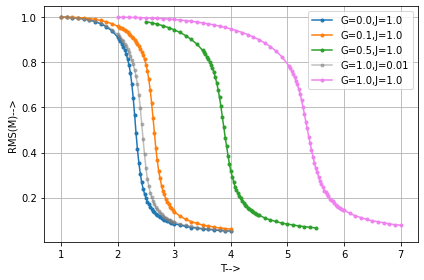

In [18]:
# ------------------------------------------------------------------------------------------------------------------------<
# Plotting all the RMS_Magnetization values for all G in a single plot
plt.figure()
plt.plot(T_list_G_0, RMS_Magnetization_list_G_0,".-",label="G=0.0,J=1.0")
plt.plot(T_list_G_0_1, RMS_Magnetization_list_G_0_1,".-",label="G=0.1,J=1.0")
plt.plot(T_list_G_0_5, RMS_Magnetization_list_G_0_5,".-",label="G=0.5,J=1.0")
plt.plot(T_list_G_1_J_0, RMS_Magnetization_list_G_1_J_0,".-",color="grey",alpha=0.5,label="G=1.0,J=0.01")
plt.plot(T_list_G_1_J_1, RMS_Magnetization_list_G_1_J_1,".-",color="violet",label="G=1.0,J=1.0")
#plt.title(f"RMS of Magnetization as function of T ")
plt.xlabel("T-->")
plt.ylabel(rf"RMS(M)-->")
plt.legend()
plt.grid()
figure_name = f"RMS_Magnetization_for_all_G.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0":list(T_list_G_0), "RMS_Magnetization_list_G_0":list(RMS_Magnetization_list_G_0),"T_list_G_0_1":list(T_list_G_0_1), "RMS_Magnetization_list_G_0_1":list(RMS_Magnetization_list_G_0_1),"T_list_G_0_5":list(T_list_G_0_5), "RMS_Magnetization_list_G_0_5":list(RMS_Magnetization_list_G_0_5),"T_list_G_1_J_0":list(T_list_G_1_J_0), "RMS_Magnetization_list_G_1_J_0":list(RMS_Magnetization_list_G_1_J_0),}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

df_dict_2 = {"T_list_G_1_J_1":list(T_list_G_1_J_1), "RMS_Magnetization_list_G_1_J_1":list(RMS_Magnetization_list_G_1_J_1)}
df_2 = pd.DataFrame(df_dict_2)
figure_data_file_path = figure_file_path[0:-4] + "_extra.csv"
df_2.to_csv(figure_data_file_path, float_format="%.4f", index=False)

# Magnetic susceptibility Plot

CPU times: user 1min 39s, sys: 3.29 s, total: 1min 42s
Wall time: 1min 42s


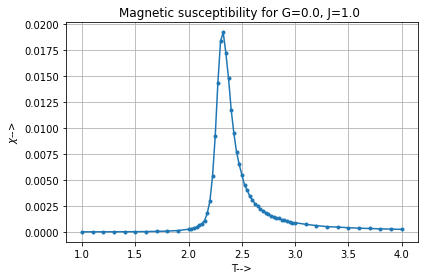

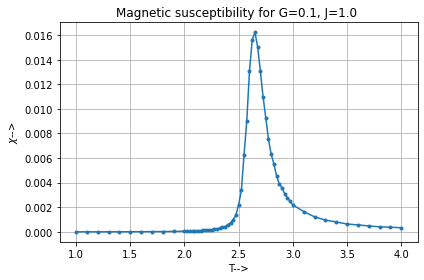

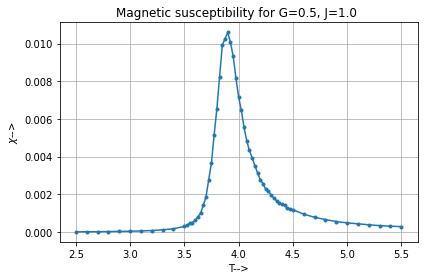

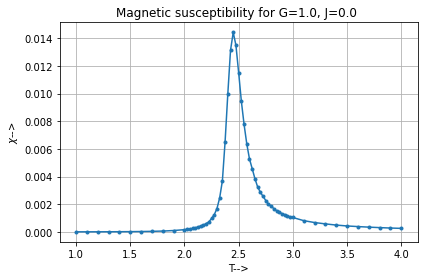

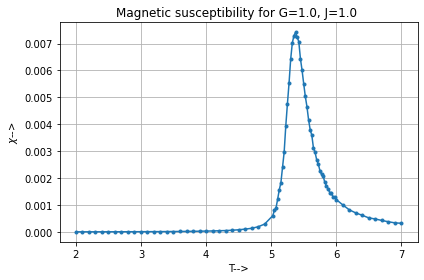

In [19]:
%%time
import numpy as np
import pickle
import os
import matplotlib.pyplot as plt



# Saving all the file names into a dictionary called data file name
data_file_names_list_G_0 = []
for file_name in os.listdir("./G_0_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_0.append(file_name)
data_file_names_list_G_0.sort()

data_file_names_list_G_0_1 = []
for file_name in os.listdir("./G_0.1_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_0_1.append(file_name)
data_file_names_list_G_0_1.sort()

data_file_names_list_G_0_5 = []
for file_name in os.listdir("./G_0.5_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_0_5.append(file_name)
data_file_names_list_G_0_5.sort()

data_file_names_list_G_1_J_0 = []
for file_name in os.listdir("./G_1_J_0_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_1_J_0.append(file_name)
data_file_names_list_G_1_J_0.sort()


data_file_names_list_G_1_J_1 = []
for file_name in os.listdir("./G_1_J_1_data_in_pkl_format"):
    if file_name.endswith('.pkl'):
        if file_name.startswith("configerations_"):
            data_file_names_list_G_1_J_1.append(file_name)
data_file_names_list_G_1_J_1.sort()

if not os.path.isdir("Generated_plots"):
    os.mkdir("Generated_plots")

# Plotting The Magnetic susceptibility as function of configerations for differenet Temperatutes at G=0.0-----------------<
T_list_G_0 = [] 
magnetic_susceptibility_list_G_0 = [] 
for configerations_file_name in data_file_names_list_G_0:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_0_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            chi = magnetic_susceptibility(Magnetization_list, T)
            magnetic_susceptibility_list_G_0.append(chi)
            T_list_G_0.append(T)


plt.figure()
plt.plot(T_list_G_0, magnetic_susceptibility_list_G_0,".-")
plt.title(f"Magnetic susceptibility for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"$\chi$-->")
plt.grid()
figure_name = f"Magnetic_susceptibility_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0":list(T_list_G_0), "magnetic_susceptibility_list_G_0":list(magnetic_susceptibility_list_G_0)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# ------------------------------------------------------------------------------------------------------------------------<


# Plotting The Magnetic susceptibility as function of configerations for differenet Temperatutes at G=0.1-----------------<
T_list_G_0_1 = [] 
magnetic_susceptibility_list_G_0_1 = [] 
for configerations_file_name in data_file_names_list_G_0_1:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_0.1_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            chi = magnetic_susceptibility(Magnetization_list, T)
            magnetic_susceptibility_list_G_0_1.append(chi)
            T_list_G_0_1.append(T)


plt.figure()
plt.plot(T_list_G_0_1, magnetic_susceptibility_list_G_0_1,".-")
plt.title(f"Magnetic susceptibility for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"$\chi$-->")
plt.grid()
figure_name = f"Magnetic_susceptibility_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0_1":list(T_list_G_0_1), "magnetic_susceptibility_list_G_0_1":list(magnetic_susceptibility_list_G_0_1)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# ------------------------------------------------------------------------------------------------------------------------<


# Plotting The Magnetic susceptibility as function of configerations for differenet Temperatutes at G=0.5-----------------<
T_list_G_0_5 = [] 
magnetic_susceptibility_list_G_0_5 = [] 
for configerations_file_name in data_file_names_list_G_0_5:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_0.5_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            chi = magnetic_susceptibility(Magnetization_list, T)
            magnetic_susceptibility_list_G_0_5.append(chi)
            T_list_G_0_5.append(T)


plt.figure()
plt.plot(T_list_G_0_5, magnetic_susceptibility_list_G_0_5,".-")
plt.title(f"Magnetic susceptibility for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"$\chi$-->")
plt.grid()
figure_name = f"Magnetic_susceptibility_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0_5":list(T_list_G_0_5), "magnetic_susceptibility_list_G_0_5":list(magnetic_susceptibility_list_G_0_5)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# ------------------------------------------------------------------------------------------------------------------------<


# Plotting The Magnetic susceptibility as function of configerations for differenet Temperatutes at G=1.0, J=0.0-----------------<
T_list_G_1_J_0 = [] 
magnetic_susceptibility_list_G_1_J_0 = [] 
for configerations_file_name in data_file_names_list_G_1_J_0:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_1_J_0_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            chi = magnetic_susceptibility(Magnetization_list, T)
            magnetic_susceptibility_list_G_1_J_0.append(chi)
            T_list_G_1_J_0.append(T)


plt.figure()
plt.plot(T_list_G_1_J_0, magnetic_susceptibility_list_G_1_J_0,".-")
plt.title(f"Magnetic susceptibility for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"$\chi$-->")
plt.grid()
figure_name = f"Magnetic_susceptibility_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_1_J_0":list(T_list_G_1_J_0), "magnetic_susceptibility_list_G_1_J_0":list(magnetic_susceptibility_list_G_1_J_0)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)


# ------------------------------------------------------------------------------------------------------------------------<


# Plotting The Magnetic susceptibility as function of configerations for differenet Temperatutes at G=1.0, J=1.0-----------------<
T_list_G_1_J_1 = [] 
magnetic_susceptibility_list_G_1_J_1 = [] 
for configerations_file_name in data_file_names_list_G_1_J_1:
    if "configerations" in configerations_file_name:
        configerations_file_path = os.path.join("./G_1_J_1_data_in_pkl_format",configerations_file_name)
        with open(configerations_file_path, 'rb') as f:
            configerations = pickle.load(f)
            Magnetization_list = [Magnetization(configerations[i, :, :]) for i in range(configerations.shape[0])]
            Magnetization_list = np.array(Magnetization_list)

            # print(configerations_file_name)
            G = float(configerations_file_name.split("_")[4])
            J = float(configerations_file_name.split("_")[6])
            T = float(configerations_file_name.split("_")[8])

            chi = magnetic_susceptibility(Magnetization_list, T)
            magnetic_susceptibility_list_G_1_J_1.append(chi)
            T_list_G_1_J_1.append(T)


plt.figure()
plt.plot(T_list_G_1_J_1, magnetic_susceptibility_list_G_1_J_1,".-")
plt.title(f"Magnetic susceptibility for G={G}, J={J} ")
plt.xlabel("T-->")
plt.ylabel(rf"$\chi$-->")
plt.grid()
figure_name = f"Magnetic_susceptibility_for_G={G}_J={J}_.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_1_J_1":list(T_list_G_1_J_1), "magnetic_susceptibility_list_G_1_J_1":list(magnetic_susceptibility_list_G_1_J_1)}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)





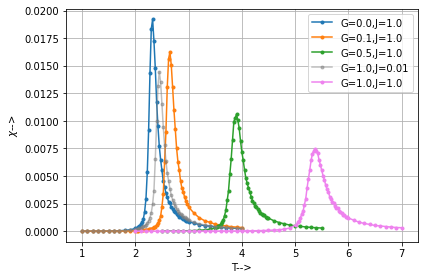

In [20]:
# ------------------------------------------------------------------------------------------------------------------------<
# Plotting all the chi values for all G in a single plot
plt.figure()
plt.plot(T_list_G_0, magnetic_susceptibility_list_G_0,".-",label="G=0.0,J=1.0")
plt.plot(T_list_G_0_1, magnetic_susceptibility_list_G_0_1,".-",label="G=0.1,J=1.0")
plt.plot(T_list_G_0_5, magnetic_susceptibility_list_G_0_5,".-",label="G=0.5,J=1.0")
plt.plot(T_list_G_1_J_0, magnetic_susceptibility_list_G_1_J_0,".-",color="grey",alpha=0.5,label="G=1.0,J=0.01")
plt.plot(T_list_G_1_J_1, magnetic_susceptibility_list_G_1_J_1,".-",color="violet",label="G=1.0,J=1.0")
#plt.title(f"Magnetic susceptibility as function of T ")
plt.xlabel("T-->")
plt.ylabel(rf"$\chi$-->")
plt.legend()
plt.grid()
figure_name = f"Magnetic_susceptibility_for_all_G.jpg"
figure_file_path = os.path.join("Generated_plots", figure_name)
plt.tight_layout()
plt.savefig(figure_file_path)
# Storing the the data related to the plot
df_dict = {"T_list_G_0":list(T_list_G_0), "magnetic_susceptibility_list_G_0":list(magnetic_susceptibility_list_G_0),"T_list_G_0_1":list(T_list_G_0_1), "magnetic_susceptibility_list_G_0_1":list(magnetic_susceptibility_list_G_0_1),"T_list_G_0_5":list(T_list_G_0_5), "magnetic_susceptibility_list_G_0_5":list(magnetic_susceptibility_list_G_0_5),"T_list_G_1_J_0":list(T_list_G_1_J_0), "magnetic_susceptibility_list_G_1_J_0":list(magnetic_susceptibility_list_G_1_J_0),}
df = pd.DataFrame(df_dict)
figure_data_file_path = figure_file_path[0:-4] + ".csv"
df.to_csv(figure_data_file_path, float_format="%.4f", index=False)

df_dict_2 = {"T_list_G_1_J_1":list(T_list_G_1_J_1), "magnetic_susceptibility_list_G_1_J_1":list(magnetic_susceptibility_list_G_1_J_1)}
df_2 = pd.DataFrame(df_dict_2)
figure_data_file_path = figure_file_path[0:-4] + "_extra.csv"
df_2.to_csv(figure_data_file_path, float_format="%.4f", index=False)

In [21]:
! zip -r Plots_for_final_paper.zip ./Generated_plots 

  adding: Generated_plots/ (stored 0%)
  adding: Generated_plots/Magnetic_susceptibility_for_G=1.0_J=0.0_.jpg (deflated 26%)
  adding: Generated_plots/Magnetic_susceptibility_for_G=1.0_J=1.0_.csv (deflated 71%)
  adding: Generated_plots/xi_b_for_G=1.0_J=1.0_.csv (deflated 64%)
  adding: Generated_plots/RMS_Magnetization_for_G=0.1_J=1.0_.jpg (deflated 30%)
  adding: Generated_plots/Magnetic_susceptibility_for_G=0.1_J=1.0_.csv (deflated 70%)
  adding: Generated_plots/xi_b_for_G=0.1_J=1.0_.jpg (deflated 43%)
  adding: Generated_plots/Magnetic_susceptibility_for_G=1.0_J=1.0_.jpg (deflated 28%)
  adding: Generated_plots/xi_b_for_G=1.0_J=0.0_.csv (deflated 63%)
  adding: Generated_plots/xi_b_for_G=1.0_J=0.0_.jpg (deflated 44%)
  adding: Generated_plots/RMS_Magnetization_for_G=0.5_J=1.0_.csv (deflated 61%)
  adding: Generated_plots/Magnetic_susceptibility_for_all_G.jpg (deflated 18%)
  adding: Generated_plots/Magnetic_susceptibility_for_G=0.5_J=1.0_.csv (deflated 68%)
  adding: Generated_plot

In [22]:
crit_region_dict = {"J":[], "G":[], "T_low_for_critical":[], "T_up_for_critical":[], "T_critical":[],"Temperature Range":[],"T_c Range":[]}
df_crit_region_temps = pd.DataFrame(crit_region_dict)

In [23]:
T_list_G_0 = np.array(T_list_G_0)
magnetic_susceptibility_list_G_0 = np.array(magnetic_susceptibility_list_G_0)
T_list_G_0_1 = np.array(T_list_G_0_1)
magnetic_susceptibility_list_G_0_1 = np.array(magnetic_susceptibility_list_G_0_1)
T_list_G_0_5 = np.array(T_list_G_0_5)
magnetic_susceptibility_list_G_0_5 = np.array(magnetic_susceptibility_list_G_0_5)
T_list_G_1_J_0 = np.array(T_list_G_1_J_0)
magnetic_susceptibility_list_G_1_J_0 = np.array(magnetic_susceptibility_list_G_1_J_0)
T_list_G_1_J_1 = np.array(T_list_G_1_J_1)
magnetic_susceptibility_list_G_1_J_1 = np.array(magnetic_susceptibility_list_G_1_J_1)
print(T_list_G_0[magnetic_susceptibility_list_G_0.argsort()[-1]],T_list_G_0[magnetic_susceptibility_list_G_0.argsort()[-2]])
print(T_list_G_0_1[magnetic_susceptibility_list_G_0_1.argsort()[-1]],T_list_G_0_1[magnetic_susceptibility_list_G_0_1.argsort()[-2]])
print(T_list_G_0_5[magnetic_susceptibility_list_G_0_5.argsort()[-1]],T_list_G_0_5[magnetic_susceptibility_list_G_0_5.argsort()[-2]])
print(T_list_G_1_J_0[magnetic_susceptibility_list_G_1_J_0.argsort()[-1]],T_list_G_1_J_0[magnetic_susceptibility_list_G_1_J_0.argsort()[-2]])
print(T_list_G_1_J_1[magnetic_susceptibility_list_G_1_J_1.argsort()[-1]],T_list_G_1_J_1[magnetic_susceptibility_list_G_1_J_1.argsort()[-2]])


print((T_list_G_0[magnetic_susceptibility_list_G_0.argsort()[-1]]+T_list_G_0[magnetic_susceptibility_list_G_0.argsort()[-2]])/2)
print((T_list_G_0_1[magnetic_susceptibility_list_G_0_1.argsort()[-1]]+T_list_G_0_1[magnetic_susceptibility_list_G_0_1.argsort()[-2]])/2)
print((T_list_G_0_5[magnetic_susceptibility_list_G_0_5.argsort()[-1]]+T_list_G_0_5[magnetic_susceptibility_list_G_0_5.argsort()[-2]])/2)
print((T_list_G_1_J_0[magnetic_susceptibility_list_G_1_J_0.argsort()[-1]]+T_list_G_1_J_0[magnetic_susceptibility_list_G_1_J_0.argsort()[-2]])/2)
print((T_list_G_1_J_1[magnetic_susceptibility_list_G_1_J_1.argsort()[-1]]+T_list_G_1_J_1[magnetic_susceptibility_list_G_1_J_1.argsort()[-2]])/2)

2.325 2.3
2.65 2.625
3.9 3.875
2.45 2.475
5.375 5.35
2.3125
2.6375
3.8875
2.4625000000000004
5.3625


## <a href="./Plots_for_final_paper.zip"> Download Final_paper_code.zip  here </a>